<a href="https://colab.research.google.com/github/Akhigbesimeon/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student GPA Predictor

## Mission:
The goal of this project is to build and deploy a regression model that predicts a college
student's GPA based on their daily habits, study patterns, and behavioral choices. The model
will be integrated into a student wellness and academic coaching app I'm building, one that
helps students figure out which habits are quietly dragging their grades down, and which ones
are worth actually investing in.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import sqlite3

## Data Acquisition

I'm using a single CSV file: college_students_habits_1M.csv, a large dataset of one million student records covering behavioral, academic, and lifestyle features.

A quick .shape check confirms we have 1,000,000 rows before any cleaning, and .head(5) gives us a first look at what the columns actually contain.

In [3]:
data = "college_students_habits_1M.csv"
df = pd.read_csv(data)

In [4]:
df.shape

(1000000, 42)

In [5]:
df.head(5)

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
0,3.014684,67.00599,51.595387,57.211285,61.653540,65.397200,4,5.993893,4.287966,58.146000,...,0,1.958940,73.727480,5.721128,3.587111,2.814086,1.814086,5.491878,0.546729,Low
1,3.665277,73.28455,69.749020,57.552320,62.062782,65.715500,3,6.949383,1.841224,41.945290,...,0,3.146447,48.468456,5.755232,4.820090,2.836821,1.836821,2.876881,0.707133,Low
2,2.703784,72.32519,92.837640,44.568970,46.482760,53.597702,2,6.703293,3.863112,56.555750,...,1,5.551245,46.623684,4.456897,5.493774,1.971265,0.971265,5.704047,0.868230,Low
3,3.445073,74.75687,85.189026,52.040790,55.448948,60.571404,2,6.498832,5.073206,65.171420,...,1,4.543216,47.909600,5.204079,5.481987,2.469386,1.469386,6.596658,0.729216,Low
4,0.192687,55.05021,64.520620,32.815000,32.378000,42.627330,5,6.552570,1.000000,30.725826,...,1,4.447042,73.316520,3.281500,2.822375,1.187667,0.187667,4.602954,0.370964,Low


## Data Cleaning & Inspection

Before modeling, I drop rows with missing values using dropna, then inspect .columns and .dtypes. The dataset is a mix of numeric habit metrics (like study_hours and screen_time) and categorical lifestyle indicators that'll need encoding before any model
can use them.

In [6]:
def clean_data(df):
    df.dropna(inplace=True)

In [7]:
df.columns

Index(['study_hours', 'attendance', 'assignment_completion', 'midterm_score',
       'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress',
       'anxiety', 'depression', 'motivation', 'concentration',
       'time_management', 'self_discipline', 'social_media_hours',
       'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity',
       'junk_food_frequency', 'caffeine_mg', 'late_night_frequency',
       'procrastination_score', 'family_income', 'parental_education_level',
       'internet_quality', 'library_visits', 'online_courses_completed',
       'part_time_hours', 'peer_study_group', 'relationship_status',
       'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day',
       'previous_gpa', 'class_participation', 'weekly_study_sessions',
       'group_study_hours', 'financial_stress', 'gpa', 'performance_level'],
      dtype='str')

In [8]:
df.dtypes

study_hours                 float64
attendance                  float64
assignment_completion       float64
midterm_score               float64
final_score                 float64
project_score               float64
backlogs                      int64
sleep_hours                 float64
stress                      float64
anxiety                     float64
depression                  float64
motivation                  float64
concentration               float64
time_management             float64
self_discipline             float64
social_media_hours          float64
gaming_hours                float64
netflix_hours               float64
screen_time                 float64
physical_activity           float64
junk_food_frequency         float64
caffeine_mg                 float64
late_night_frequency        float64
procrastination_score       float64
family_income               float64
parental_education_level      int64
internet_quality            float64
library_visits              

## GPA Distribution

The histogram shows how GPA is spread across the dataset. Most students sit between 0.5
and 1.5, with the distribution close to normal. That's a reasonable starting point for
regression, the model won't be fighting extreme skew or a heavily imbalanced target.

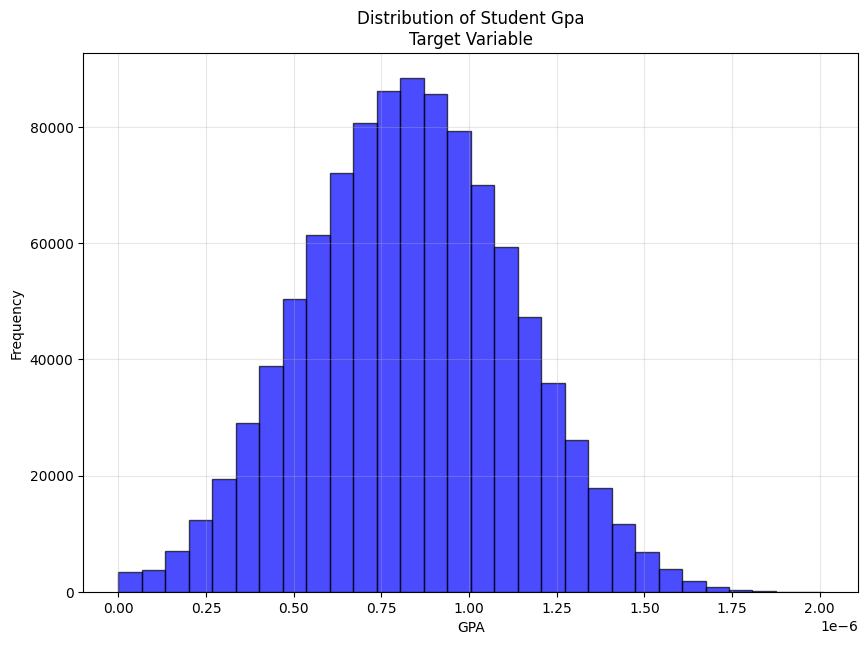

In [9]:
plt.figure(figsize=(10, 7))

plt.hist(df['gpa'] / 1000000, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.title('Distribution of Student Gpa\nTarget Variable')
plt.grid(True, alpha=0.3)

Originally i had selected a few features to see how non curricular attributes affect a student's GPA, but i decide to widen my focus because i saw very low correlation from my selected features

C:\Users\Sb\AppData\Local\Temp\ipykernel_16828\2130675726.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


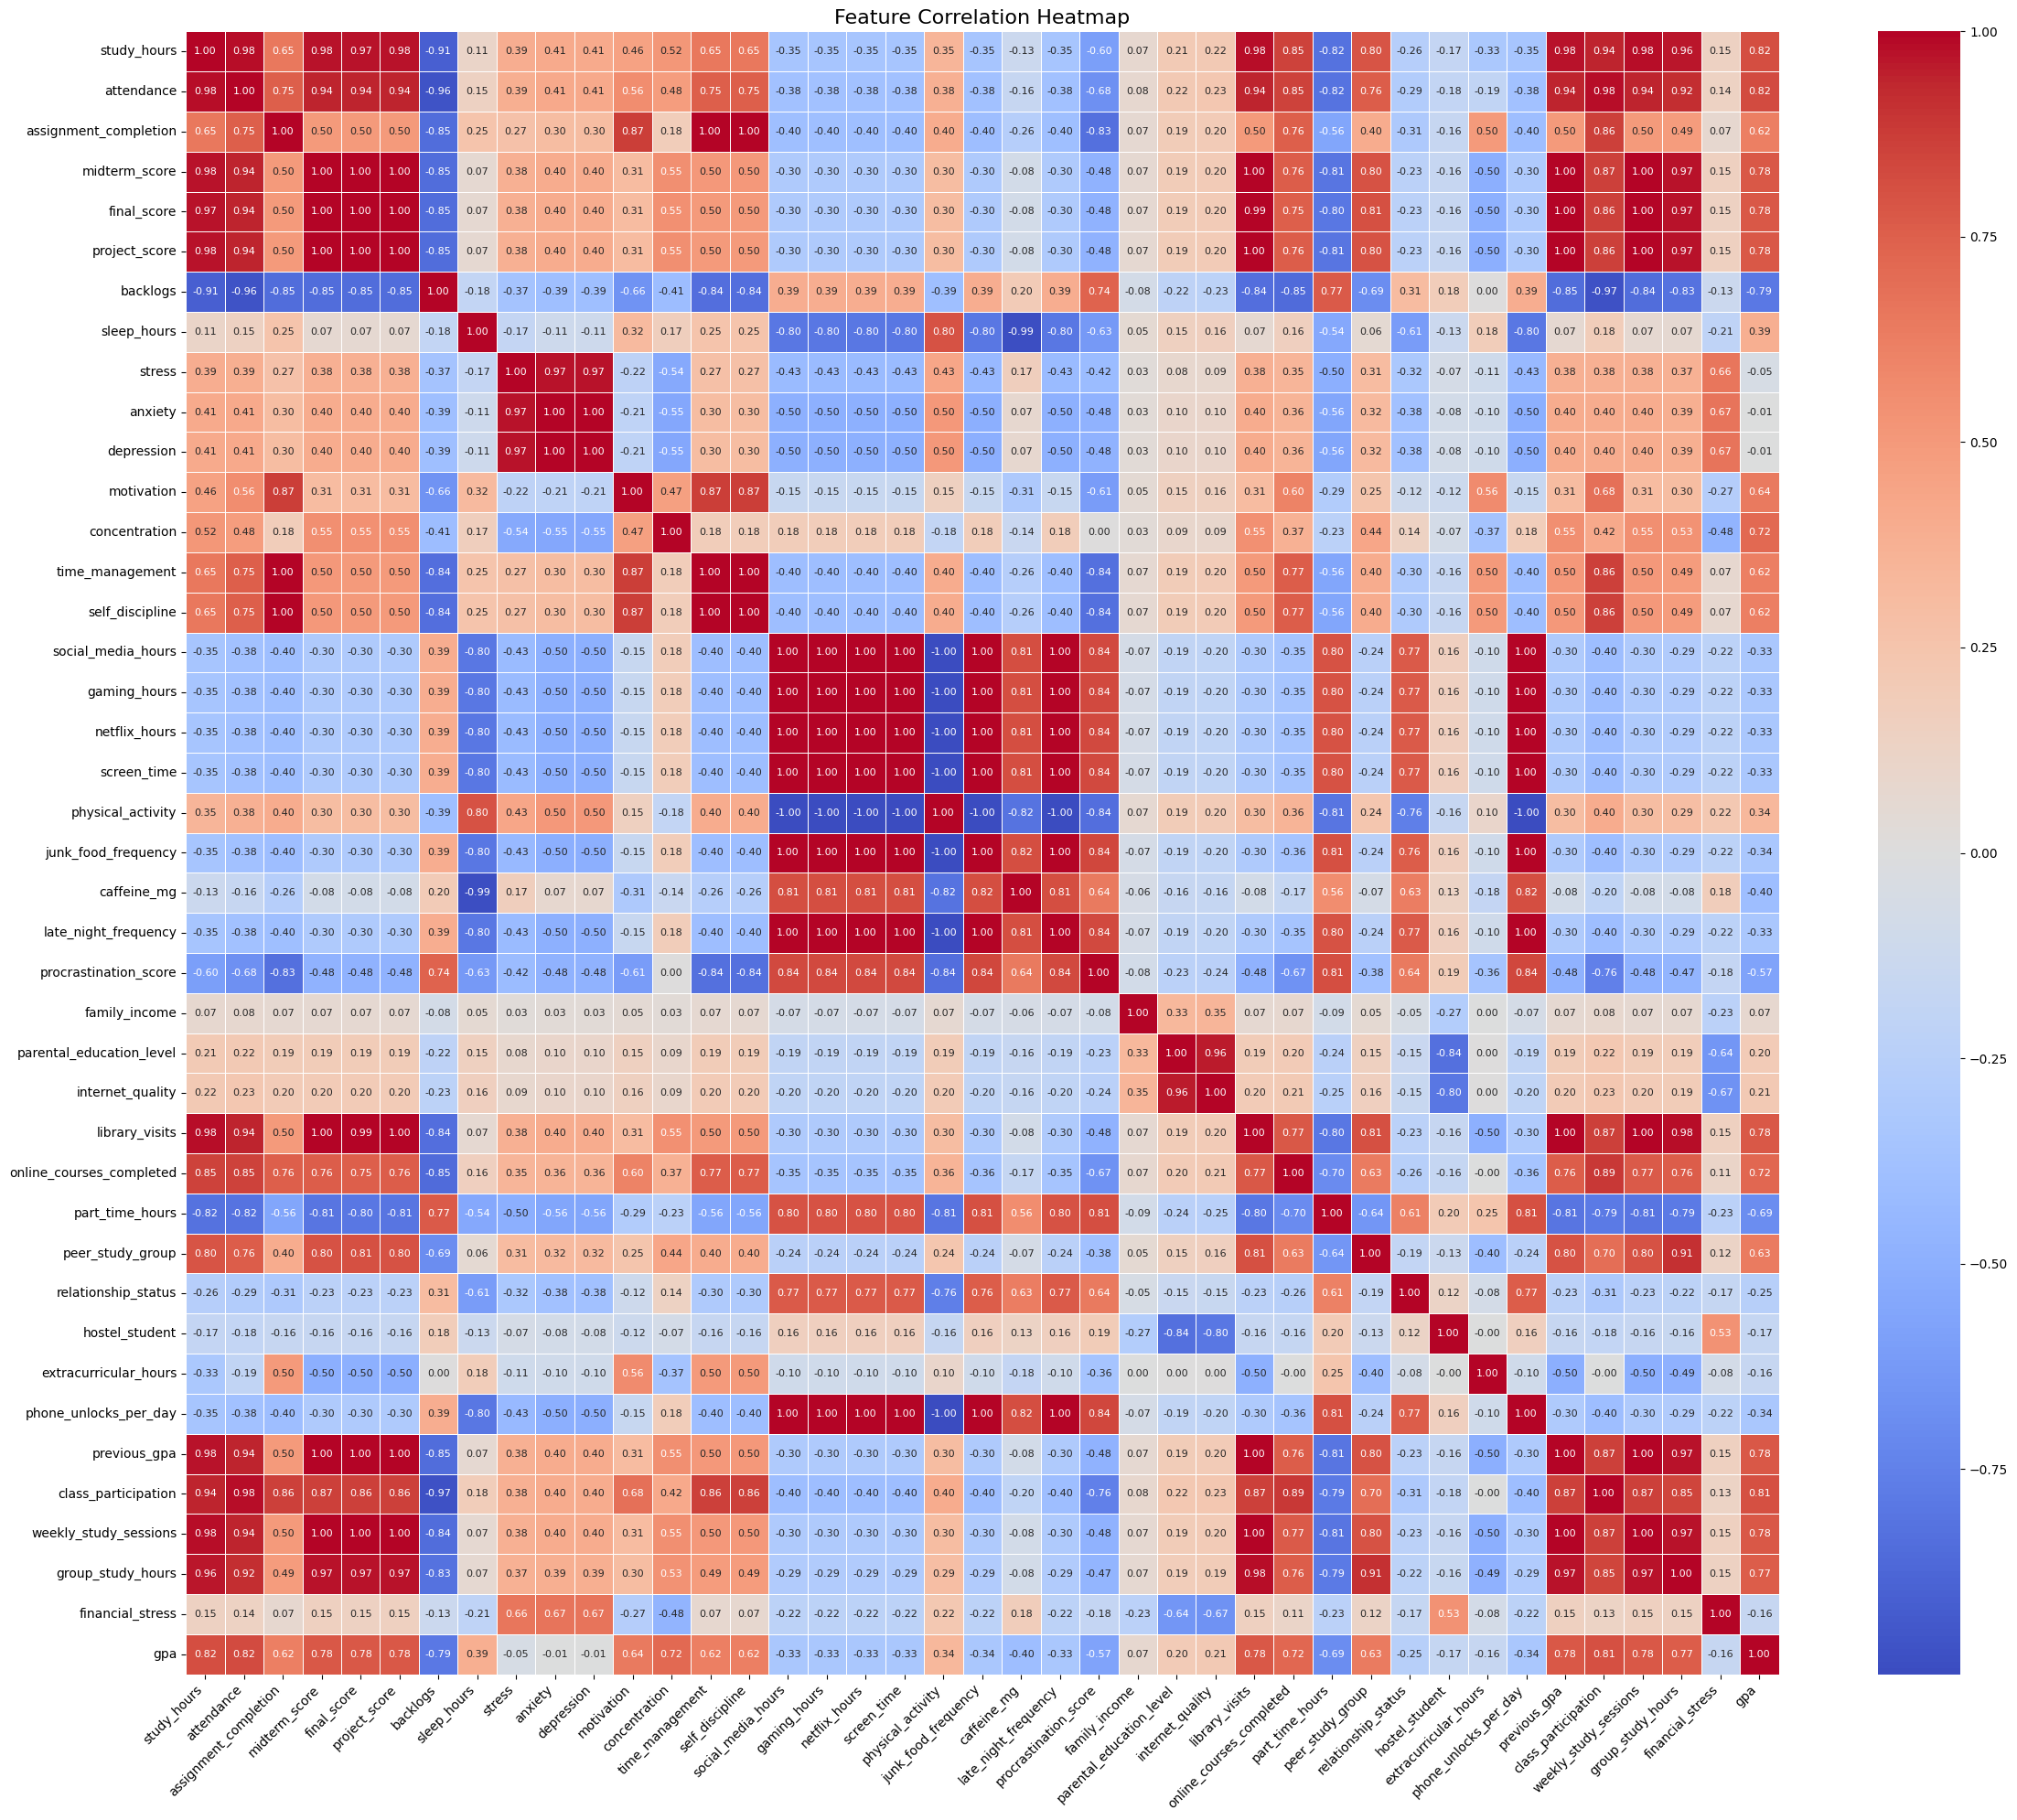

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

plt.figure(figsize=(24, 20))

correlation_matrix_all = df_encoded.corr()

sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## Heatmap Interpretation

The full correlation matrix surfaced three problems before any model training could happen.

### 1. Target Leakage

`midterm_score`, `final_score`, `project_score`, and `previous_gpa` all correlate with
GPA at around 0.78 — and with each other at nearly 1.00. These aren't predictors; they're
just the answer in disguise. A model trained on them isn't learning student behavior, it's
learning that grades predict grades. All four get dropped.

### 2. Redundant Feature Blocks

Two clusters of features are essentially the same measurement repeated under different names:

- **Study block:** attendance, library_visits, class_participation,
  weekly_study_sessions, and group_study_hours all correlate above 0.90 with each
  other and with study_hours. I keep study_hours and drop the rest.

- **Digital/physical block:** social_media_hours, gaming_hours, netflix_hours,
  late_night_frequency, and phone_unlocks_per_day correlate at 1.00 with screen_time.
  physical_activity is perfectly inversely correlated (-1.00) with the same group. I keep
  screen_time only.

- **Mental health block:** stress, anxiety, and depression are nearly identical to
  each other and show near-zero correlation with GPA. All three are dropped.

### 3. The Actual Behavioral Predictors

With the noise cleared out, the features that genuinely move GPA are:

- **Positive:** study_hours (0.82), concentration (0.72), online_courses_completed (0.72)
- **Negative:** backlogs (-0.79), part_time_hours (-0.69), `procrastination_score (-0.57)

In [ ]:
columns_to_drop = [
    'midterm_score', 'final_score', 'project_score', 'previous_gpa',
    'attendance', 'library_visits', 'class_participation',
    'weekly_study_sessions', 'group_study_hours',
    'social_media_hours', 'gaming_hours', 'netflix_hours',
    'late_night_frequency', 'phone_unlocks_per_day', 'physical_activity',
    'stress', 'anxiety', 'depression',
    'family_income', 'financial_stress', 'extracurricular_hours',
    'hostel_student', 'internet_quality', 'parental_education_level'
]

df_model = df_encoded.drop(columns=columns_to_drop, errors='ignore')

X = df_model.drop('gpa', axis=1)
y = df_model['gpa'] * (4.0 / 2.01)

print(f"Original feature count: {df_encoded.shape[1]}")
print(f"Optimized feature count: {X.shape[1]}")

Original feature count: 41
Optimized feature count: 16


## Data Visualization: Correlations and Key Predictors

With target leakage and multicollinearity resolved, two visualizations confirm the cleaned
feature set behaves as expected.

1. **Focused correlation heatmap:** Instead of the full matrix, this one shows each feature's
   relationship to GPA specifically. It confirms that study habits sit at the top and
   procrastination at the bottom — which is exactly what we'd expect.

2. **Scatterplots:** study_hours vs. GPA and procrastination_score vs. GPA. The linear
   trends are clear in both, which validates the decision to use regression rather than a
   more complex non-linear approach for this dataset.

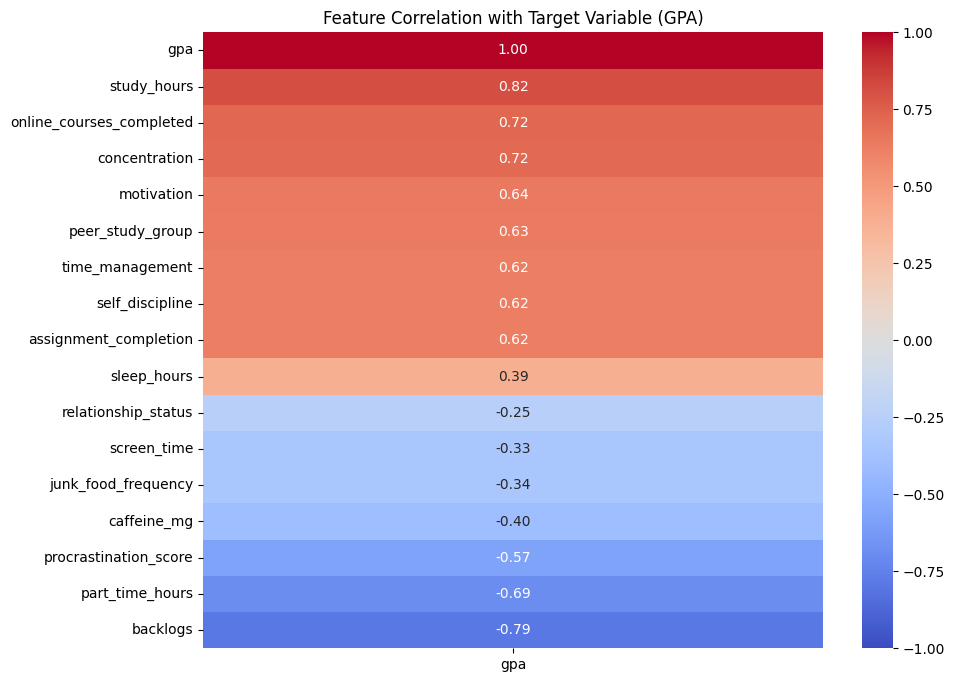

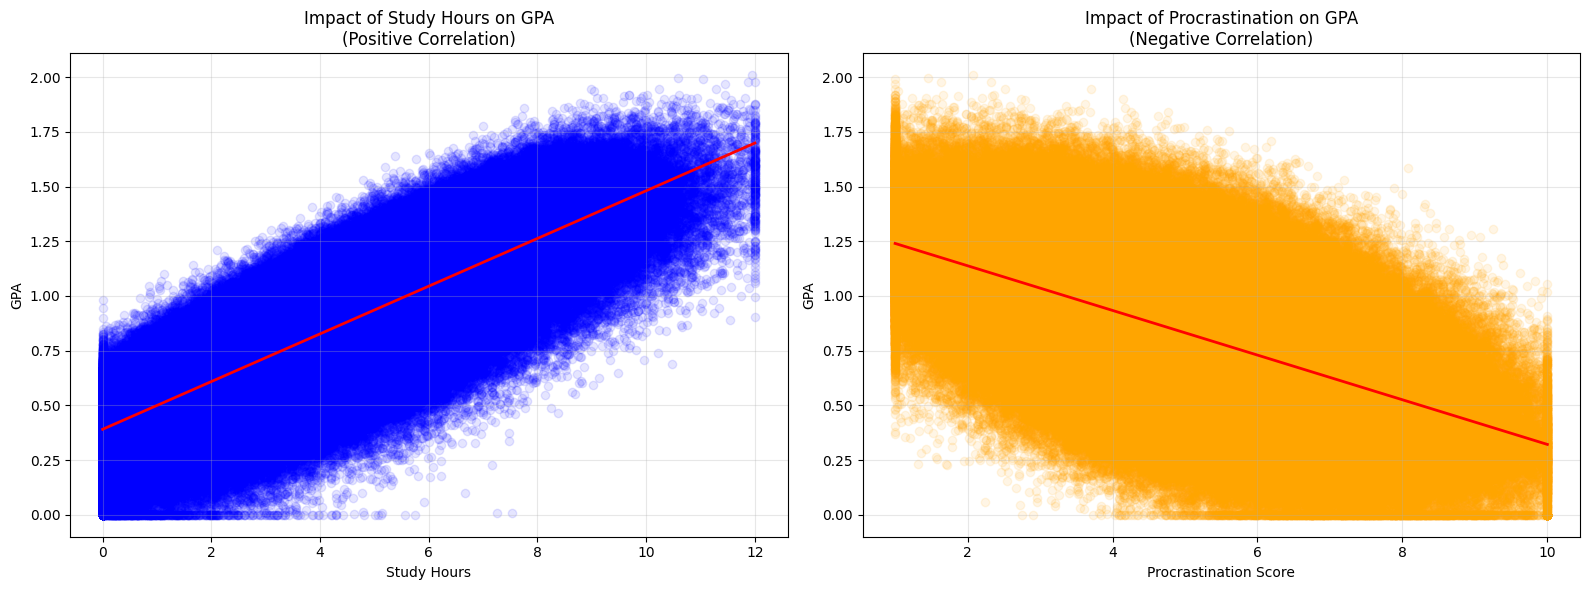

In [24]:
plt.figure(figsize=(10, 8))

corr_matrix = df_model.corr()

gpa_corr = corr_matrix[['gpa']].sort_values(by='gpa', ascending=False)

sns.heatmap(gpa_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Feature Correlation with Target Variable (GPA)")
plt.show()

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.regplot(data=df_model, x='study_hours', y='gpa',
            scatter_kws={'alpha': 0.1, 'color': 'blue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Impact of Study Hours on GPA\n(Positive Correlation)')
plt.xlabel('Study Hours')
plt.ylabel('GPA')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.regplot(data=df_model, x='procrastination_score', y='gpa',
            scatter_kws={'alpha': 0.1, 'color': 'orange'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Impact of Procrastination on GPA\n(Negative Correlation)')
plt.xlabel('Procrastination Score')
plt.ylabel('GPA')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Data Splitting and Standardization
Before training, I split the dataset into an 80% training set and a 20% testing set. It is critical to split the data *before* scaling to prevent data leakage.

Because the features operate on vastly different scales (e.g., hours of screen time vs. milligrams of caffeine), the data must be standardized. I used StandardScaler to transform the data so that it has a mean of 0 and a standard deviation of 1. This is an absolute requirement for the linear regression model, as i am optimizing it via Stochastic Gradient Descent (SGDRegressor), an algorithm that is highly sensitive to unscaled feature magnitudes.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Model Training and Comparison

I trained four regression algorithms on the same scaled dataset:

- **Linear Regression**: the baseline; assumes a direct linear relationship between
  habits and GPA
- **Gradient Descent LR (SGDRegressor)**: same family as Linear Regression but optimized
  iteratively via stochastic gradient descent, which lets us inspect convergence behavior
- **Decision Tree**: captures non-linear patterns without requiring feature scaling;
  useful for catching interaction effects the linear models miss
- **Random Forest**: an ensemble of decision trees; generally more robust, reduces
  overfitting, and handles complex feature interactions better than a single tree

Each model is evaluated across MSE, RMSE, MAE, MAPE, and R². The model with the lowest
MSE on the test set is selected for saving and deployment.

In [26]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {
    'Linear Regression': LinearRegression(),
    'Gradient Descent LR': SGDRegressor(
        random_state=42,
        tol=1e-3,
        learning_rate='adaptive',
        eta0=0.01
    ),
    'Decision Tree': DecisionTreeRegressor(
        random_state=42,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10
    ),
    'Random Forest': RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=15,
        min_samples_split=15,
        n_jobs=-1
    )
}

results = {}
best_model_name = None
best_model_obj = None
best_mse = float('inf')

print(" Student GPA Predictor Results  ")

for name, model in models.items():
    try:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mse)

        mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

        results[name] = {
            'model': model,
            'mse': mse,
            'mae': mae,
            'r2': r2,
            'rmse': rmse,
            'mape': mape,
            'predictions': y_pred
        }

        print(f"\n[*] {name}:")
        print(f"    MSE: {mse:.4f}")
        print(f"    RMSE: {rmse:.4f} ")
        print(f"    MAE: {mae:.4f} ")

        if mape > 1000:
            print(f"    MAPE: N/A (Contains zero-value targets)")
        else:
            print(f"    MAPE: {mape:.1f}%")

        print(f"    R² Score: {r2:.4f}")

        if mse < best_mse:
            best_mse = mse
            best_model_name = name
            best_model_obj = model

    except Exception as e:
        print(f"[!] Error training {name}: {str(e)}")
        continue

 Student GPA Predictor Results  

[*] Linear Regression:
    MSE: 0.0102
    RMSE: 0.1011 
    MAE: 0.0806 
    MAPE: N/A (Contains zero-value targets)
    R² Score: 0.8832

[*] Gradient Descent LR:
    MSE: 0.0102
    RMSE: 0.1011 
    MAE: 0.0806 
    MAPE: N/A (Contains zero-value targets)
    R² Score: 0.8831

[*] Decision Tree:
    MSE: 0.0108
    RMSE: 0.1041 
    MAE: 0.0831 
    MAPE: N/A (Contains zero-value targets)
    R² Score: 0.8760

[*] Random Forest:
    MSE: 0.0102
    RMSE: 0.1008 
    MAE: 0.0804 
    MAPE: N/A (Contains zero-value targets)
    R² Score: 0.8840


## Single Student Prediction Test

After training, the best model runs a prediction on one student from the test set. The
student's behavioral profile (study hours, screen time, concentration, and procrastination
score) is printed alongside the actual GPA, the predicted GPA, and the error margin in
GPA points.

In [27]:
feature_columns = X.columns

print(f"\n[+] Best performing model: {best_model_name}")
print(f"[+] Best MSE: {best_mse:.4f}")

print(f"\n Single Student GPA Prediction Test ")
sample_idx = 5500

sample_features_scaled = X_test_scaled[sample_idx].reshape(1, -1)

student_habits = X_test.iloc[sample_idx]

actual_gpa = y_test.iloc[sample_idx]
predicted_gpa = best_model_obj.predict(sample_features_scaled)[0]

print("[i] Student Profile (Key Habits):")
print(f"    - Study Hours: {student_habits.get('study_hours', 'N/A')}")
print(f"    - Screen Time (Hours): {student_habits.get('screen_time', 'N/A')}")
print(f"    - Concentration Score: {student_habits.get('concentration', 'N/A')}")
print(f"    - Procrastination Score: {student_habits.get('procrastination_score', 'N/A')}")

print(f"\n[i] Academic Prediction:")
print(f"    Actual GPA: {actual_gpa:.2f}")
print(f"    Predicted GPA: {predicted_gpa:.2f}")
print(f"    Error Margin: {abs(actual_gpa - predicted_gpa):.2f} GPA points")


[+] Best performing model: Random Forest
[+] Best MSE: 0.0102

 Single Student GPA Prediction Test 
[i] Student Profile (Key Habits):
    - Study Hours: 5.6607437
    - Screen Time (Hours): 4.5361876
    - Concentration Score: 7.729536
    - Procrastination Score: 2.4375675

[i] Academic Prediction:
    Actual GPA: 1.01
    Predicted GPA: 1.33
    Error Margin: 0.32 GPA points


## Gradient Descent: Learning Curve

To see how the SGDRegressor converges, I run it manually for 100 epochs using
partial_fit, recording training and test loss at each step. The resulting curve shows
whether the model learns steadily or oscillates — and whether the gap between training
and test loss grows in a way that suggests overfitting.

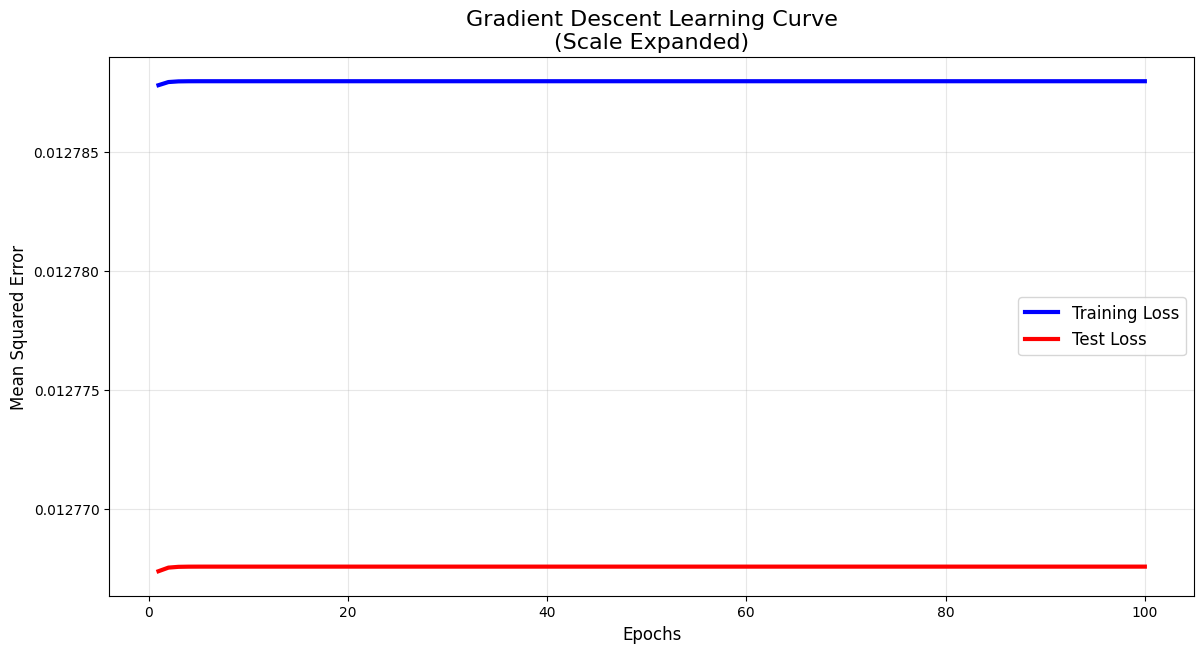

In [28]:
plt.figure(figsize=(14, 7))
sgd_viz = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42, eta0=0.01, learning_rate='adaptive')
train_errors, test_errors = [], []

for epoch in range(1, 101):
    sgd_viz.partial_fit(X_train_scaled, y_train)
    train_errors.append(mean_squared_error(y_train, sgd_viz.predict(X_train_scaled)))
    test_errors.append(mean_squared_error(y_test, sgd_viz.predict(X_test_scaled)))

plt.plot(range(1, 101), train_errors, label='Training Loss', linewidth=3, color='blue')
plt.plot(range(1, 101), test_errors, label='Test Loss', linewidth=3, color='red')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Gradient Descent Learning Curve\n(Scale Expanded)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Actual vs. Predicted GPA: All Four Models

Each model gets its own scatter plot: actual GPA on the x-axis, predicted GPA on the
y-axis. The red dashed diagonal is the perfect prediction line; the tighter the scatter
clusters around it, the better the model. R² and MAE are annotated directly on each
subplot so comparisons don't require cross-referencing a separate table.

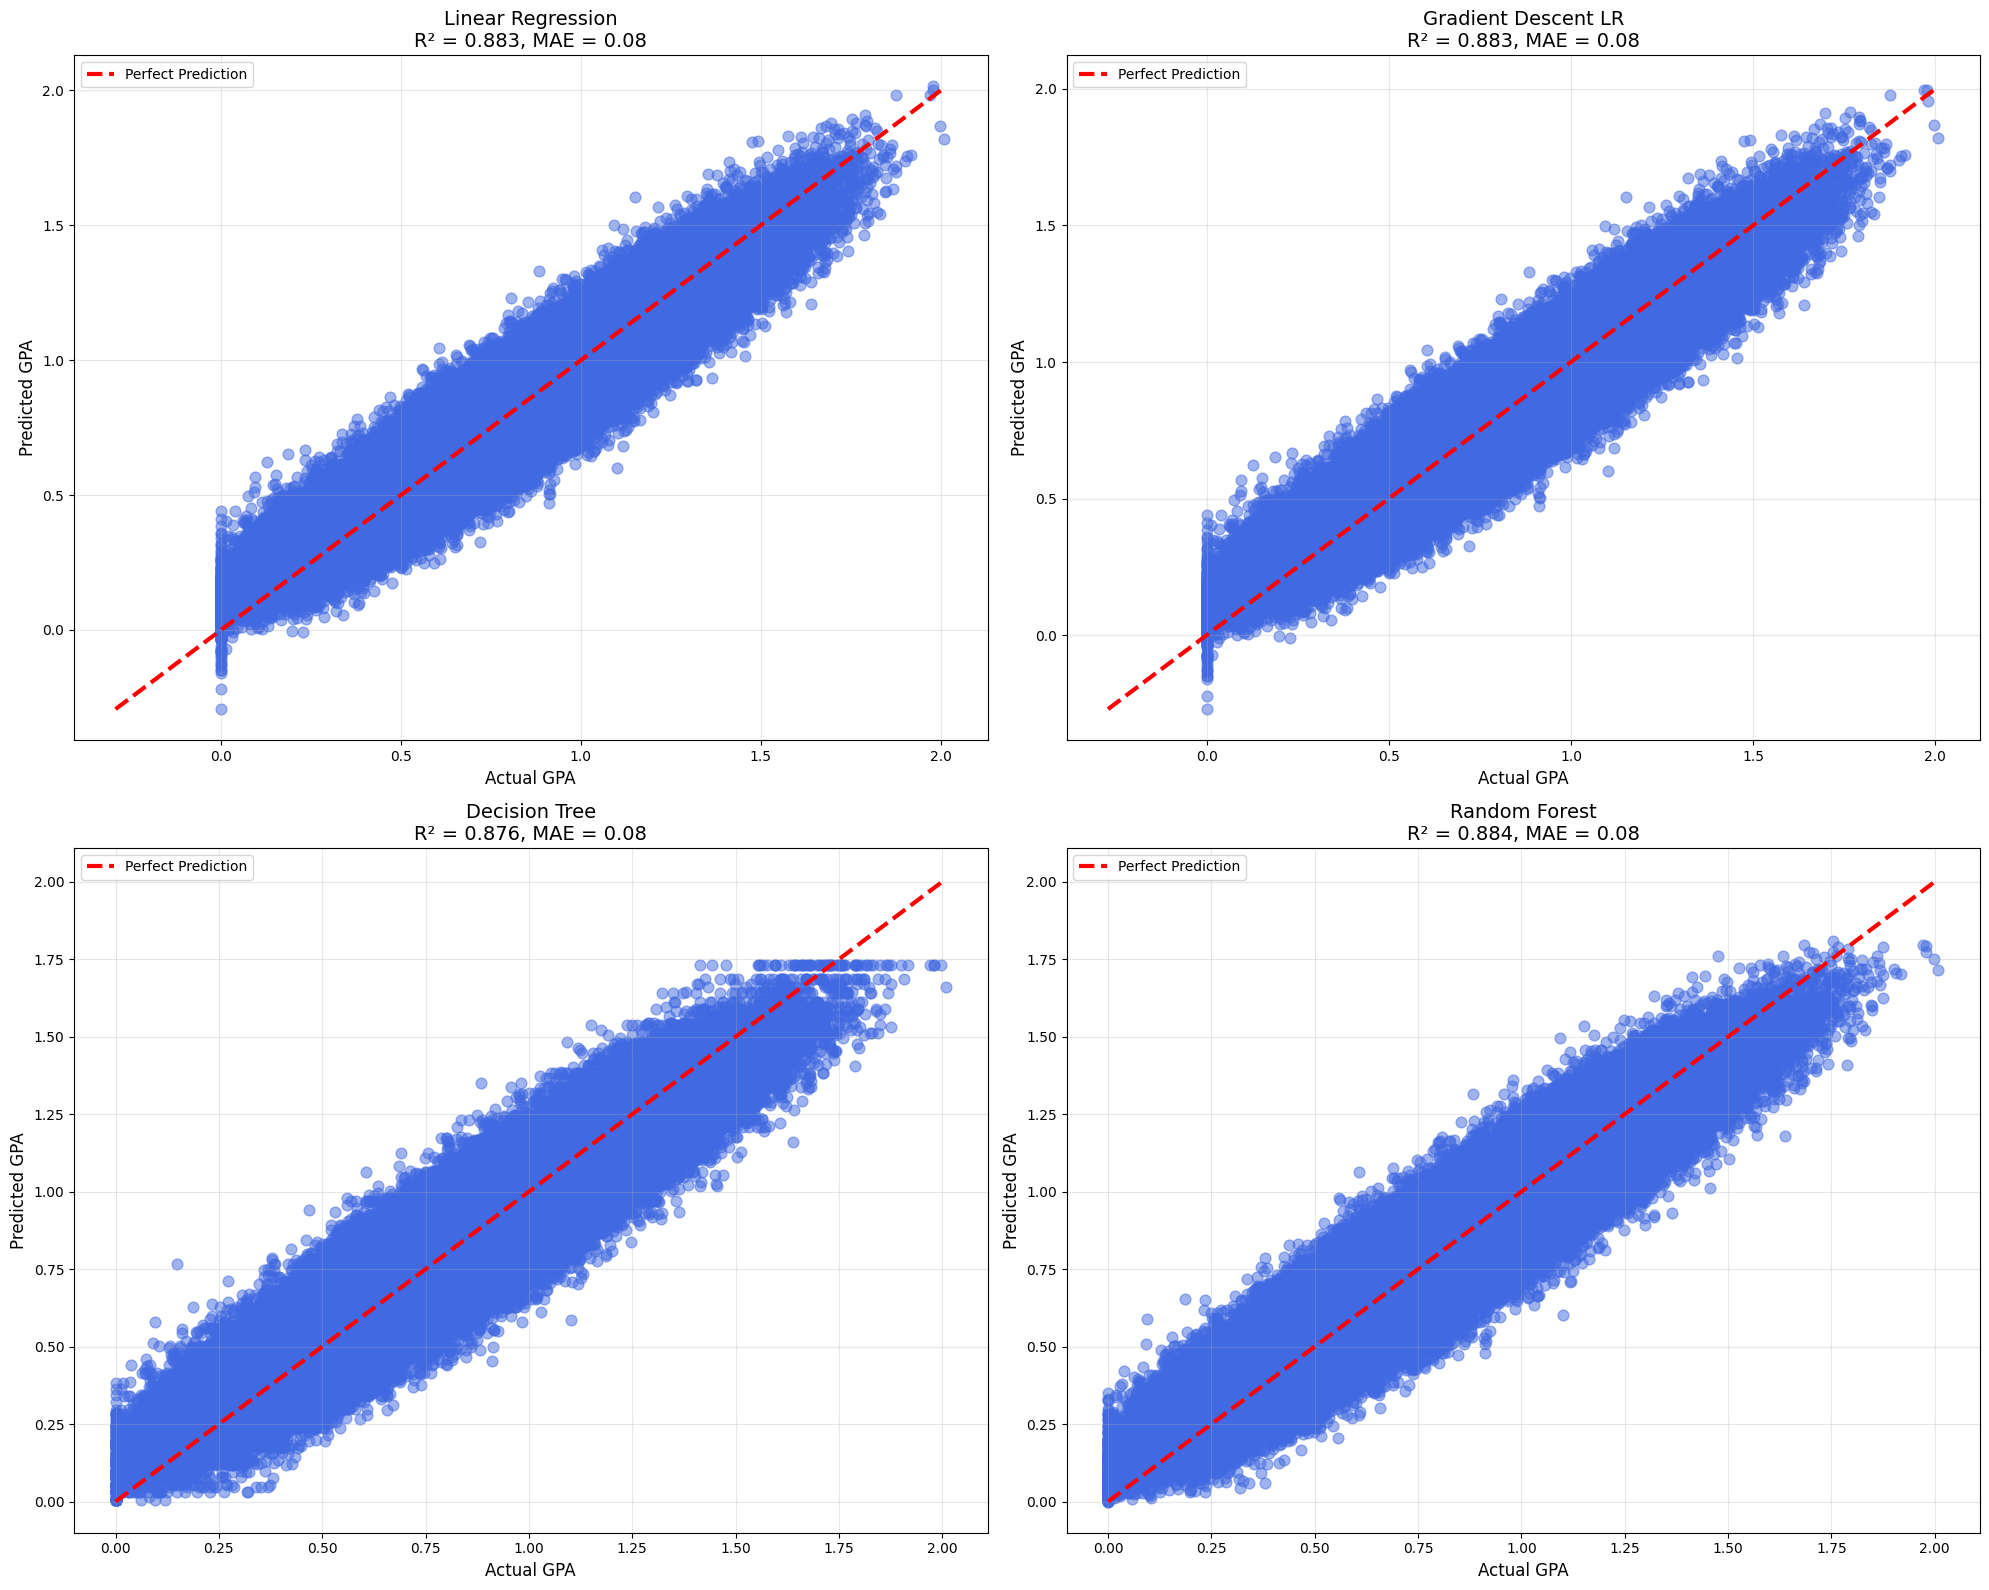

In [29]:
plt.figure(figsize=(20, 16))

for i, (name, metrics) in enumerate(results.items()):
    plt.subplot(2, 2, i+1)

    y_pred = metrics['predictions']
    r2 = metrics['r2']
    mae = metrics['mae']

    plt.scatter(y_test, y_pred, alpha=0.5, s=60, color='royalblue')

    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=3, label='Perfect Prediction')

    plt.xlabel('Actual GPA', fontsize=12)
    plt.ylabel('Predicted GPA', fontsize=12)
    plt.title(f'{name}\nR² = {r2:.3f}, MAE = {mae:.2f}', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance

For tree-based models, the chart shows which features drove predictions most using the
built-in feature_importances_ attribute. For linear models, it plots the absolute
coefficient magnitudes instead — a proxy for the same question. Either way, the chart
answers: which student habits does this model actually rely on when estimating GPA?

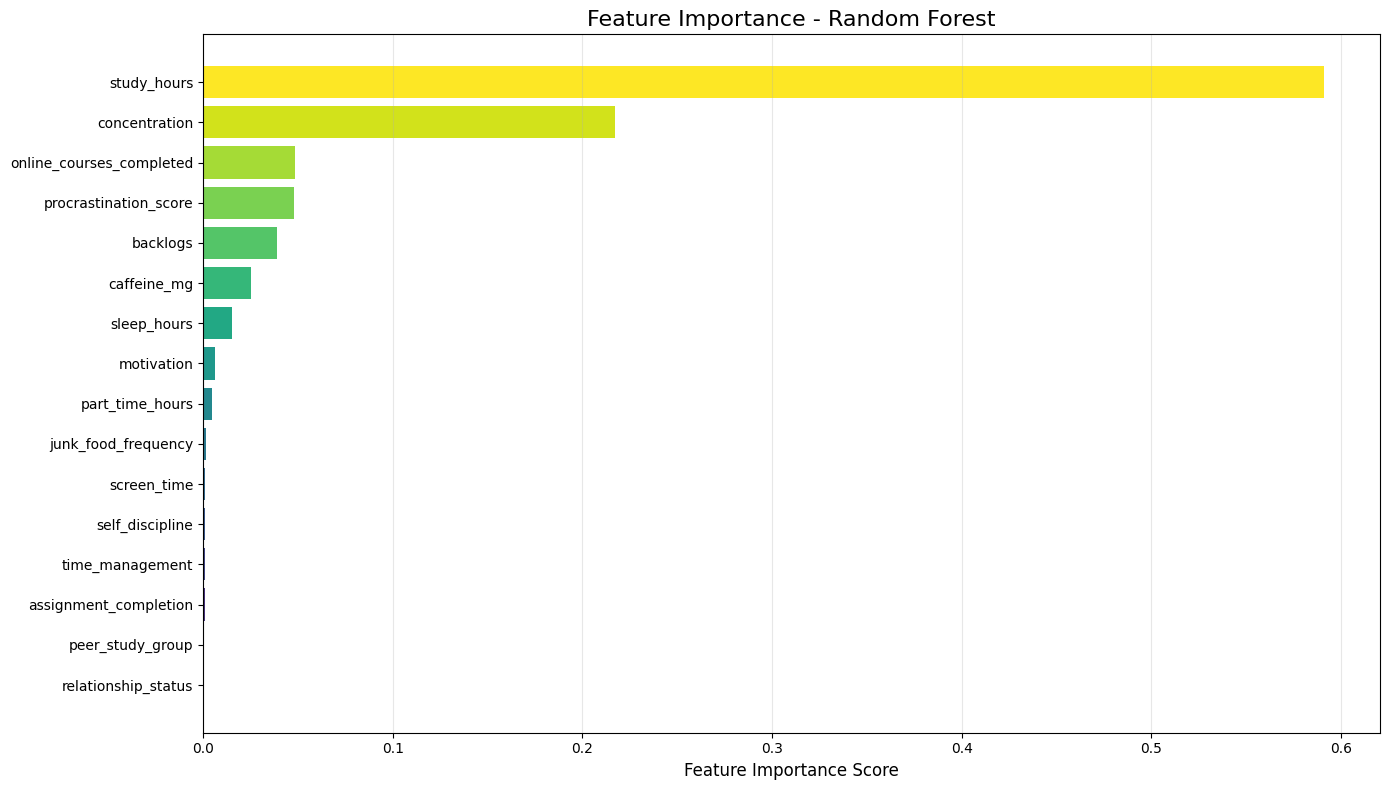

In [30]:
plt.figure(figsize=(14, 8))

if hasattr(best_model_obj, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=True)

    colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
    plt.xlabel('Feature Importance Score', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=16)
else:
    coefficients = pd.DataFrame({
        'feature': feature_columns,
        'importance': abs(best_model_obj.coef_)
    }).sort_values('importance', ascending=True)

    colors = plt.cm.plasma(np.linspace(0, 1, len(coefficients)))
    plt.barh(coefficients['feature'], coefficients['importance'], color=colors)
    plt.xlabel('Coefficient Magnitude (Absolute Value)', fontsize=12)
    plt.title('Feature Impact - Linear Regression Model', fontsize=16)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Model Performance Comparison

Three bar charts compare all four models across R², MAE, and RMSE:

- **R²:** Higher is better. A score of 1.0 means the model explains all variance in GPA;
  closer to 0 means it's not much better than predicting the mean every time.
- **MAE:** Lower is better. This is the average prediction error in GPA points (the most)
  interpretable metric for this use case.
- **RMSE:** Lower is better. Penalizes large errors more than MAE does; useful for spotting
  models that are occasionally way off even if their average error looks acceptable.

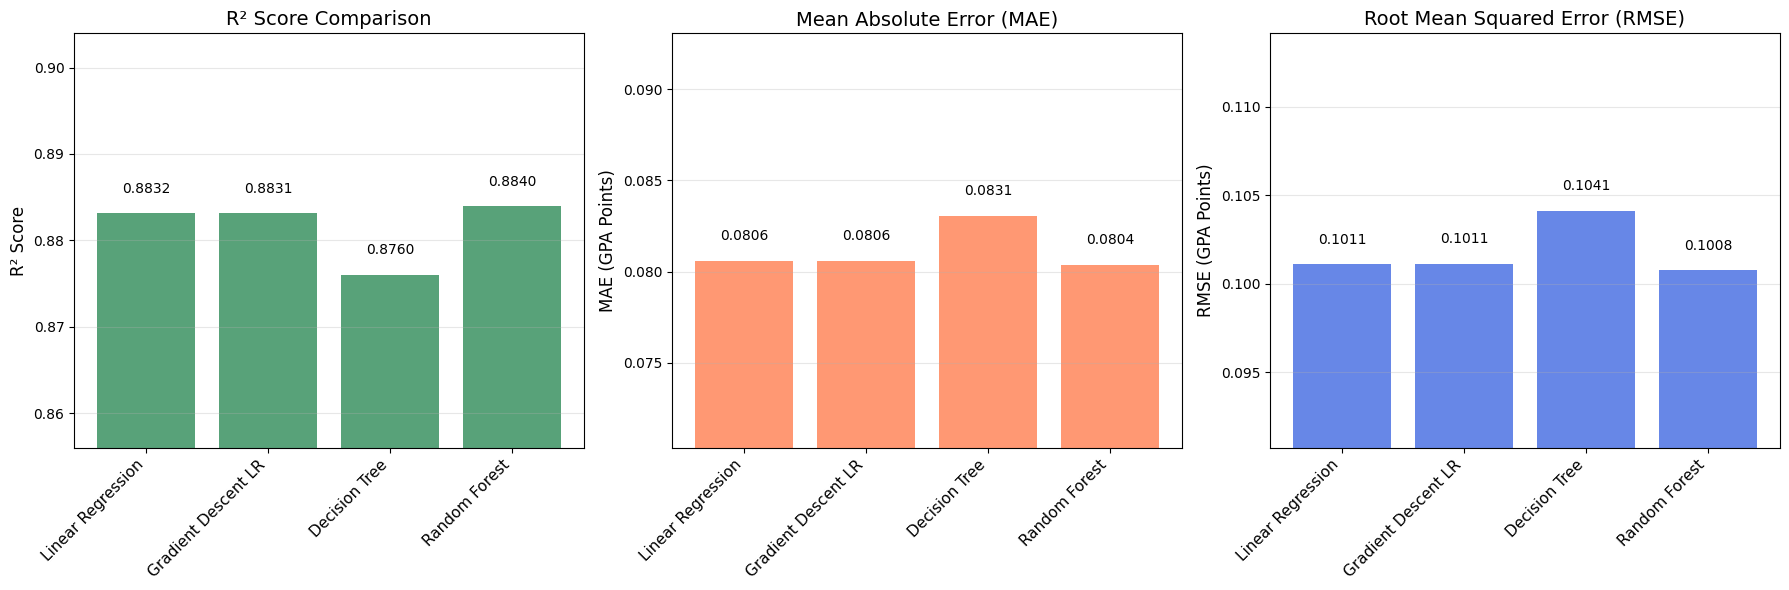

In [31]:
plt.figure(figsize=(18, 6))

model_names = list(results.keys())
r2_scores = [results[name]['r2'] for name in model_names]
mae_scores = [results[name]['mae'] for name in model_names]
rmse_scores = [results[name]['rmse'] for name in model_names]

plt.subplot(1, 3, 1)
bars1 = plt.bar(model_names, r2_scores, color='seagreen', alpha=0.8)
plt.ylim(max(0, min(r2_scores) - 0.02), max(r2_scores) + 0.02)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Score Comparison', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.subplot(1, 3, 2)
bars2 = plt.bar(model_names, mae_scores, color='coral', alpha=0.8)
plt.ylim(max(0, min(mae_scores) - 0.01), max(mae_scores) + 0.01)
plt.ylabel('MAE (GPA Points)', fontsize=12)
plt.title('Mean Absolute Error (MAE)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.subplot(1, 3, 3)
bars3 = plt.bar(model_names, rmse_scores, color='royalblue', alpha=0.8)
plt.ylim(max(0, min(rmse_scores) - 0.01), max(rmse_scores) + 0.01)
plt.ylabel('RMSE (GPA Points)', fontsize=12)
plt.title('Root Mean Squared Error (RMSE)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Model Saving and Prediction Function

The best model and its preprocessing objects are saved with joblib:

- **best_gpa_model.pkl**: the trained model weights
- **gpa_scaler.pkl**: the fitted StandardScaler, necessary to transform new inputs the
  same way the training data was transformed
- **gpa_feature_columns.pkl**: the ordered list of feature names the model expects,
  preventing column order mismatches at inference time

The predict_student_gpa function wraps the full pipeline. It takes a student's key
behavioral inputs, fills any missing one-hot encoded columns with 0, scales the input,
runs the prediction, and clamps the output to a valid GPA range of 0.0–4.0.

A quick test confirms everything works end to end: a profile with high study hours, low
screen time, and no backlogs returns a GPA in the expected upper range.

In [42]:
# [+] 1. Force the notebook to select and save Linear Regression
deploy_model_name = 'Random Forest'  # Change this to the desired model name from the results
deploy_model_obj = results[deploy_model_name]['model']

import joblib
joblib.dump(deploy_model_obj, 'best_gpa_model.pkl')
joblib.dump(scaler, 'gpa_scaler.pkl')
joblib.dump(feature_columns, 'gpa_feature_columns.pkl')

print(f"[*] Successfully saved {deploy_model_name} and preprocessing artifacts.")

# [+] 2. Define the prediction function
def predict_student_gpa(study_hours, screen_time, concentration, procrastination_score, backlogs=0, part_time_hours=0):
    input_data = {
        'study_hours': study_hours,
        'screen_time': screen_time,
        'concentration': concentration,
        'procrastination_score': procrastination_score,
        'backlogs': backlogs,
        'part_time_hours': part_time_hours
    }

    input_df = pd.DataFrame([input_data])

    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_columns]

    input_scaled = scaler.transform(input_df)
    prediction = deploy_model_obj.predict(input_scaled)[0]

    # If the raw prediction is 4.5, this clamps it to 4.0
    return max(0.0, min(10.0, prediction))

print("\n[i] Prediction Function Test")

# [+] 3. Test an AVERAGE student to bypass the 4.0 ceiling
sample_pred = predict_student_gpa(
    study_hours=6,            # Average study time
    screen_time=10,            # High screen time
    concentration=3,          # Mediocre concentration
    procrastination_score=6,  # High procrastination
    backlogs=1                # 1 backlog class
)

print(f"[*] Test Input Profile  -> Average Study, High Screen Time, 1 Backlog")
print(f"[*] Predicted GPA       -> {sample_pred:.2f}")
print(f"[*] Model R² Confidence -> {results[deploy_model_name]['r2']*100:.1f}%\n")

[*] Successfully saved Random Forest and preprocessing artifacts.

[i] Prediction Function Test
[*] Test Input Profile  -> Average Study, High Screen Time, 1 Backlog
[*] Predicted GPA       -> 0.60
[*] Model R² Confidence -> 88.4%

